# Exploratory Data Analysis

**Focus:** Charging demand trends, station utilization distributions, diurnal patterns, and dynamic pricing implications.

Note: All visualizations in this report are designed to directly inform the dynamic pricing agent parameters.*

In [11]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

from src.config import *
from src.utils import *

setup_plot_style()

## Loading Engineered Features

In [12]:
df = load_csv(FEATURES_CSV)
print(f"Dataset: {df.shape}")
print(f"\nData sources: {df['data_source'].value_counts().to_dict()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Stations: {df['station_id'].nunique()}")

2026-05-30 23:53:16 | utils                     | INFO    | Loading CSV: c:\Users\USER\Desktop\Proj\notebooks\..\data\processed\features_engineered.csv
2026-05-30 23:53:19 | utils                     | INFO    |   → Shape: (192731, 36) | Columns: ['station_id', 'timestamp', 'session_count', 'total_energy_kwh', 'avg_energy_kwh', 'avg_duration_min', 'avg_charging_min', 'charger_utilization_rate', 'energy_kwh', 'data_source', 'volume_kwh', 'active_chargers', 'price_per_kwh', 'total_chargers', 'is_cbd', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'day_of_month', 'time_period', 'revenue_per_session', 'energy_cost_per_kwh', 'queue_length_proxy', 'occupancy_density', 'demand_lag_1', 'demand_lag_2', 'demand_lag_6', 'demand_lag_24', 'energy_rolling_1h', 'energy_rolling_6h', 'energy_rolling_24h', 'charger_rolling_1h', 'charger_rolling_6h', 'charger_rolling_24h']


Dataset: (192731, 36)

Data sources: {'UrbanEV': 177840, 'ACN': 14891}
Date range: 2018-04-25 11:00:00 to 2022-07-18 23:00:00
Stations: 301


In [13]:
# Separate by data source for source-specific analysis
acn = df[df["data_source"] == "ACN"].copy()
urbanev = df[df["data_source"] == "UrbanEV"].copy()
print(f"ACN rows: {len(acn):,}, UrbanEV rows: {len(urbanev):,}")

ACN rows: 14,891, UrbanEV rows: 177,840


## Long-Term Energy Demand Trends

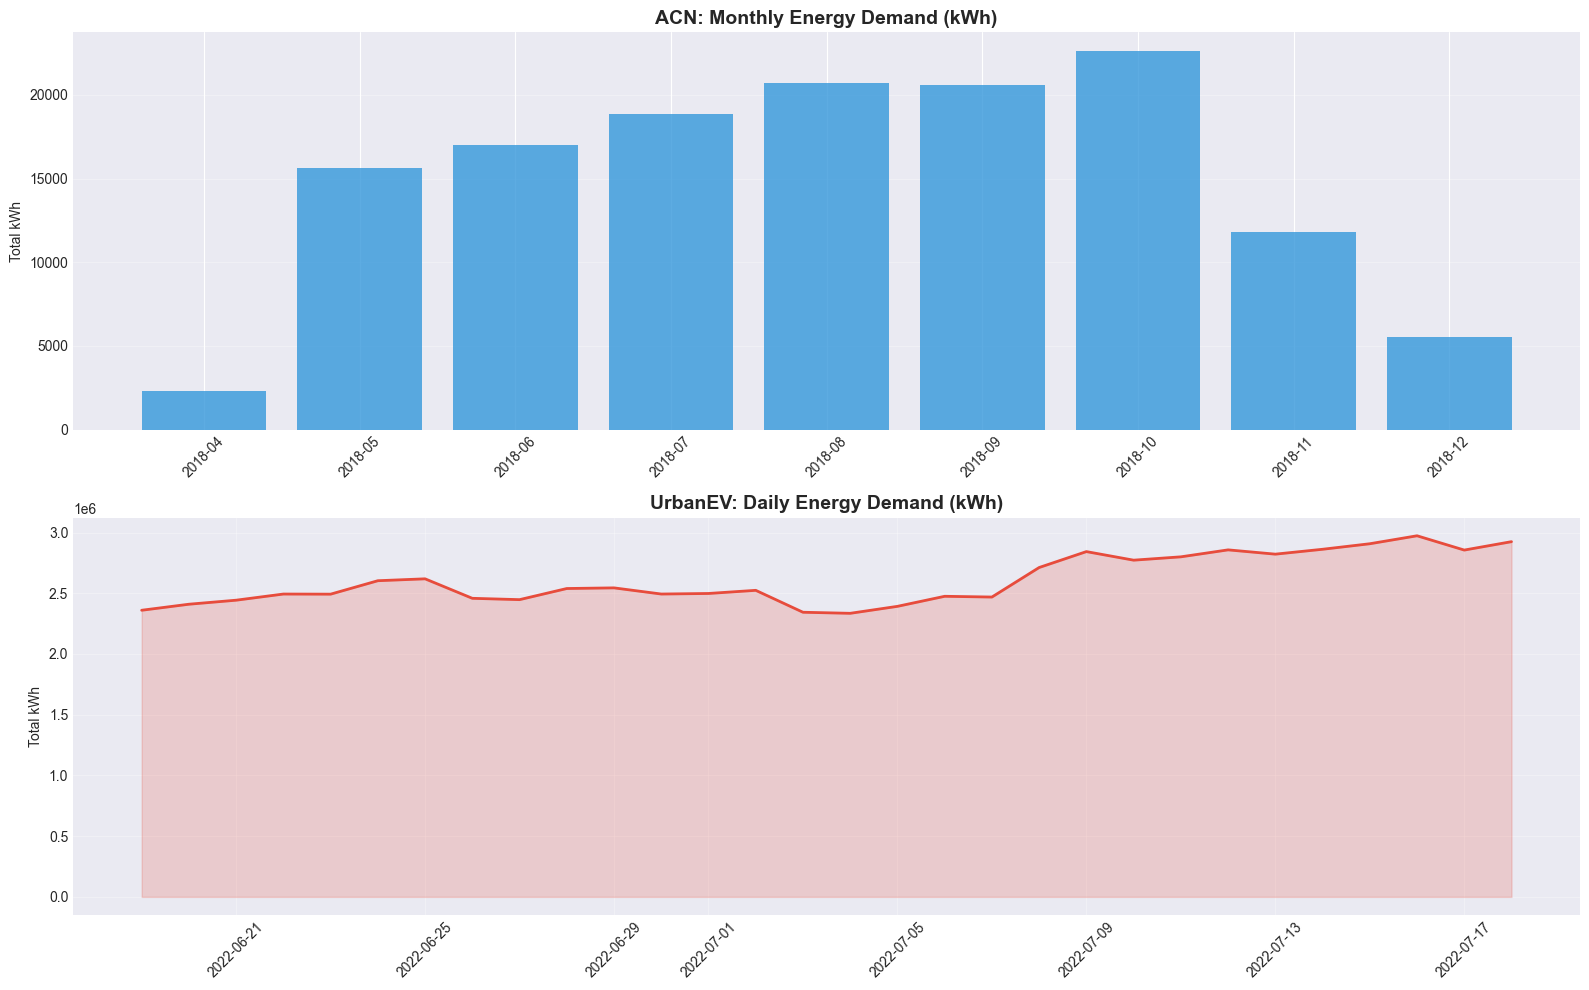

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ACN: Monthly energy demand over time
if not acn.empty and "timestamp" in acn.columns:
    acn_ts = acn.copy()
    acn_ts["timestamp"] = pd.to_datetime(acn_ts["timestamp"])
    monthly = acn_ts.groupby(acn_ts["timestamp"].dt.to_period("M"))["energy_kwh"].sum()
    axes[0].bar(monthly.index.astype(str), monthly.values, color="#3498db", alpha=0.8)
    axes[0].set_title("ACN: Monthly Energy Demand (kWh)", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Total kWh")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(axis="y", alpha=0.3)

# UrbanEV: Daily energy demand
if not urbanev.empty and "timestamp" in urbanev.columns:
    uv_ts = urbanev.copy()
    uv_ts["timestamp"] = pd.to_datetime(uv_ts["timestamp"])
    daily = uv_ts.groupby(uv_ts["timestamp"].dt.date)["energy_kwh"].sum()
    axes[1].plot(daily.index, daily.values, color="#e74c3c", linewidth=2)
    axes[1].fill_between(daily.index, daily.values, alpha=0.2, color="#e74c3c")
    axes[1].set_title("UrbanEV: Daily Energy Demand (kWh)", fontsize=14, fontweight="bold")
    axes[1].set_ylabel("Total kWh")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "eda_demand_trends.png"), dpi=150, bbox_inches="tight")
plt.show()

**Pricing Insight:** Demand shows clear seasonal and daily cycles. Dynamic pricing should adapt to these patterns — higher rates during predictably high-demand periods, discounts during troughs.

## Diurnal Intraday Heatmaps

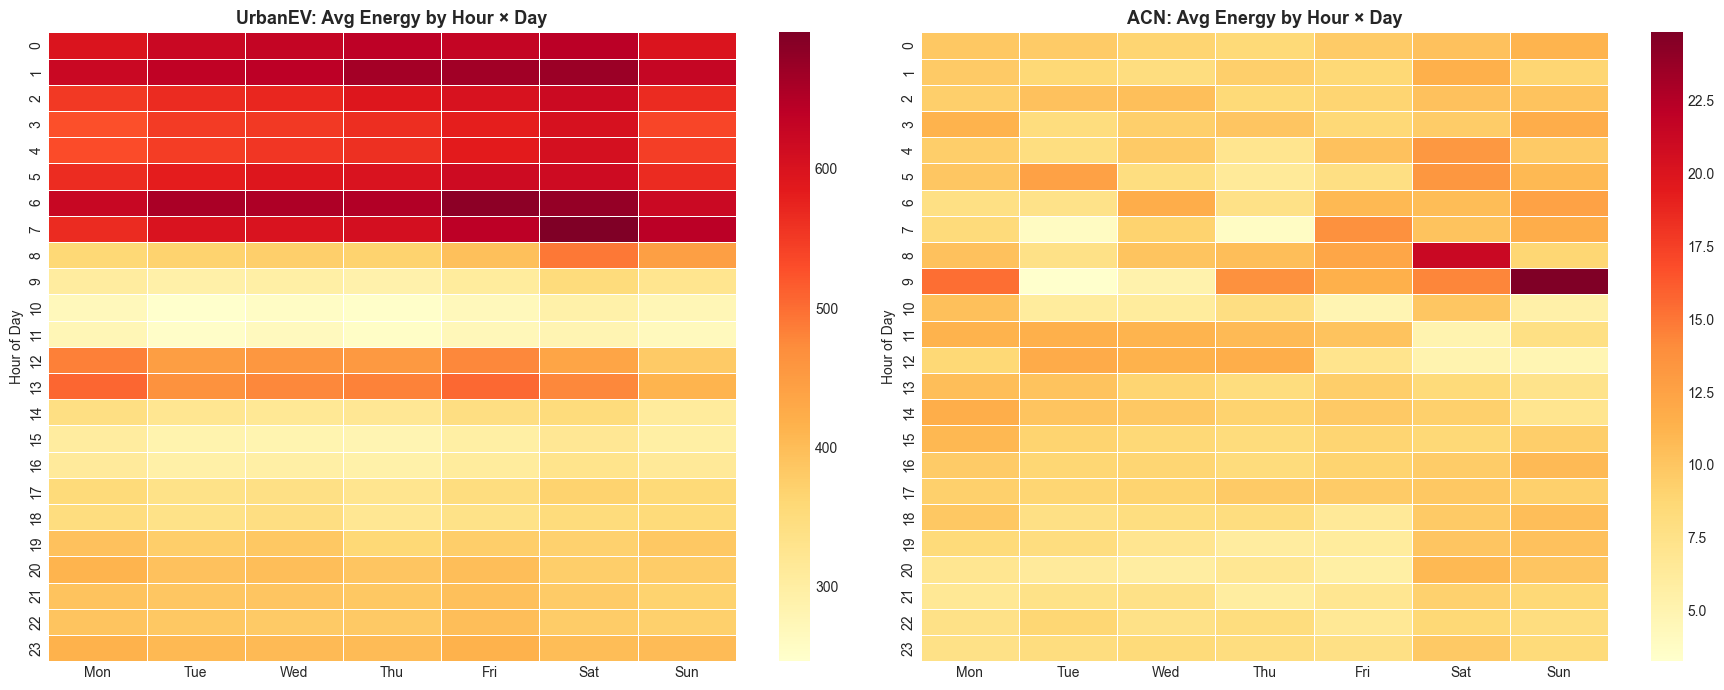

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap: Hour × Day of Week for energy demand
# Diurnal pattern highlights peak intervals to guide optimizer constraints
if "hour_of_day" in df.columns and "day_of_week" in df.columns:
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    # UrbanEV heatmap (more granular data)
    if not urbanev.empty:
        pivot = urbanev.pivot_table(
            values="energy_kwh", index="hour_of_day", columns="day_of_week",
            aggfunc="mean"
        )
        pivot.columns = [day_names[d] for d in pivot.columns]
        sns.heatmap(pivot, cmap="YlOrRd", annot=False, ax=axes[0], linewidths=0.5)
        axes[0].set_title("UrbanEV: Avg Energy by Hour × Day", fontsize=13, fontweight="bold")
        axes[0].set_ylabel("Hour of Day")

    # ACN heatmap
    if not acn.empty:
        pivot2 = acn.pivot_table(
            values="energy_kwh", index="hour_of_day", columns="day_of_week",
            aggfunc="mean"
        )
        pivot2.columns = [day_names[d] for d in pivot2.columns]
        sns.heatmap(pivot2, cmap="YlOrRd", annot=False, ax=axes[1], linewidths=0.5)
        axes[1].set_title("ACN: Avg Energy by Hour × Day", fontsize=13, fontweight="bold")
        axes[1].set_ylabel("Hour of Day")

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "eda_intraday_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

**Pricing Insight:** Clear peak hours visible (typically 8-12 AM and 5-9 PM for workplace charging). Dynamic pricing should apply surge multipliers during these windows.

## Weekday and Weekend Load Comparison

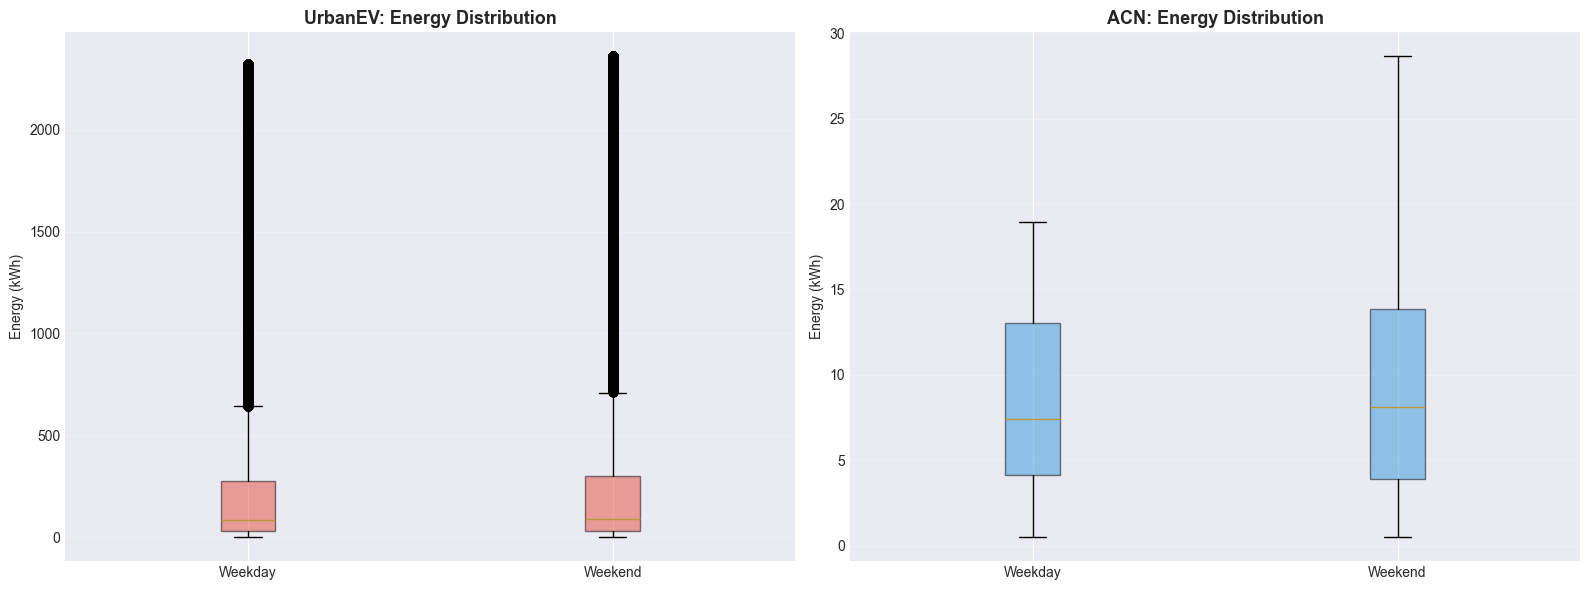

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Energy by weekday/weekend
for i, (src, data, color) in enumerate([
    ("UrbanEV", urbanev, "#e74c3c"),
    ("ACN", acn, "#3498db"),
]):
    if data.empty or "is_weekend" not in data.columns:
        continue
    weekday = data[data["is_weekend"] == 0]["energy_kwh"]
    weekend = data[data["is_weekend"] == 1]["energy_kwh"]

    axes[i].boxplot(
        [weekday.dropna().clip(0, weekday.quantile(0.95)),
         weekend.dropna().clip(0, weekend.quantile(0.95))],
        labels=["Weekday", "Weekend"],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.5),
    )
    axes[i].set_title(f"{src}: Energy Distribution", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Energy (kWh)")
    axes[i].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "eda_weekday_weekend.png"), dpi=150, bbox_inches="tight")
plt.show()

**Pricing Insight:** Weekend demand patterns differ from weekday. Tariff schedules should have separate weekday and weekend profiles.

## Volatility and Demand Variance by Tariff Period

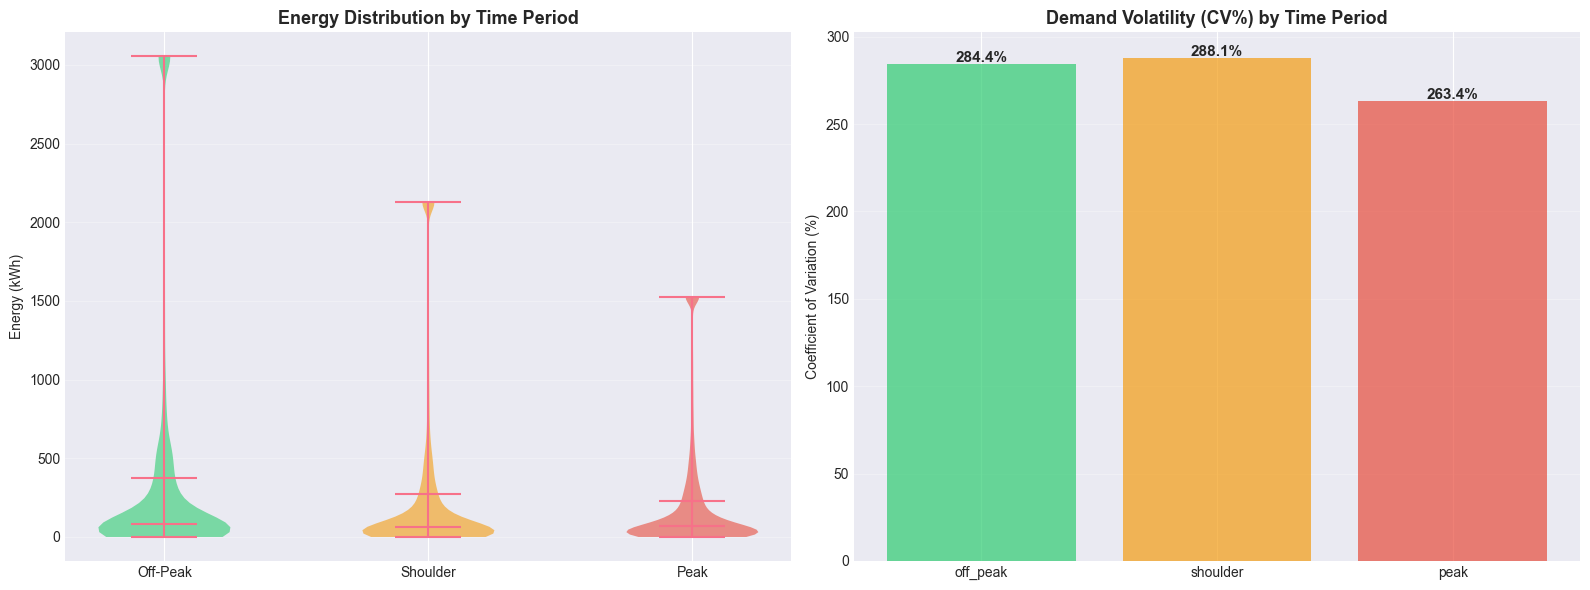

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if "time_period" in df.columns:
    period_order = ["off_peak", "shoulder", "peak"]
    colors = {"off_peak": "#2ecc71", "shoulder": "#f39c12", "peak": "#e74c3c"}

    # Violin plot of energy by time period
    period_data = []
    for period in period_order:
        subset = df[df["time_period"] == period]["energy_kwh"].dropna()
        if not subset.empty:
            period_data.append(subset.clip(0, subset.quantile(0.95)))
    
    if period_data:
        parts = axes[0].violinplot(period_data, showmeans=True, showmedians=True)
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(list(colors.values())[i])
            pc.set_alpha(0.6)
        axes[0].set_xticks([1, 2, 3])
        axes[0].set_xticklabels(["Off-Peak", "Shoulder", "Peak"])
        axes[0].set_title("Energy Distribution by Time Period", fontsize=13, fontweight="bold")
        axes[0].set_ylabel("Energy (kWh)")
        axes[0].grid(axis="y", alpha=0.3)

    # Coefficient of Variation by period
    cv_data = []
    for period in period_order:
        subset = df[df["time_period"] == period]["energy_kwh"].dropna()
        if not subset.empty:
            cv = subset.std() / subset.mean() * 100
            cv_data.append({"period": period, "cv": cv, "mean": subset.mean(), "std": subset.std()})
    cv_df = pd.DataFrame(cv_data)
    
    if not cv_df.empty:
        bars = axes[1].bar(cv_df["period"], cv_df["cv"],
                          color=[colors[p] for p in cv_df["period"]], alpha=0.7)
        axes[1].set_title("Demand Volatility (CV%) by Time Period", fontsize=13, fontweight="bold")
        axes[1].set_ylabel("Coefficient of Variation (%)")
        axes[1].grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, cv_df["cv"]):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "eda_peak_volatility.png"), dpi=150, bbox_inches="tight")
plt.show()

**Pricing Insight:** Higher volatility during peak periods creates pricing uncertainty. Surge multipliers should account for this variance — wider pricing bands during volatile periods.

## Empirical Station Utilization Density


Utilization Summary:
  Below 30% (discount eligible): 56.6% of time slots
  Above 80% (surge eligible): 7.6% of time slots
  Normal band (30-80%): 35.7% of time slots


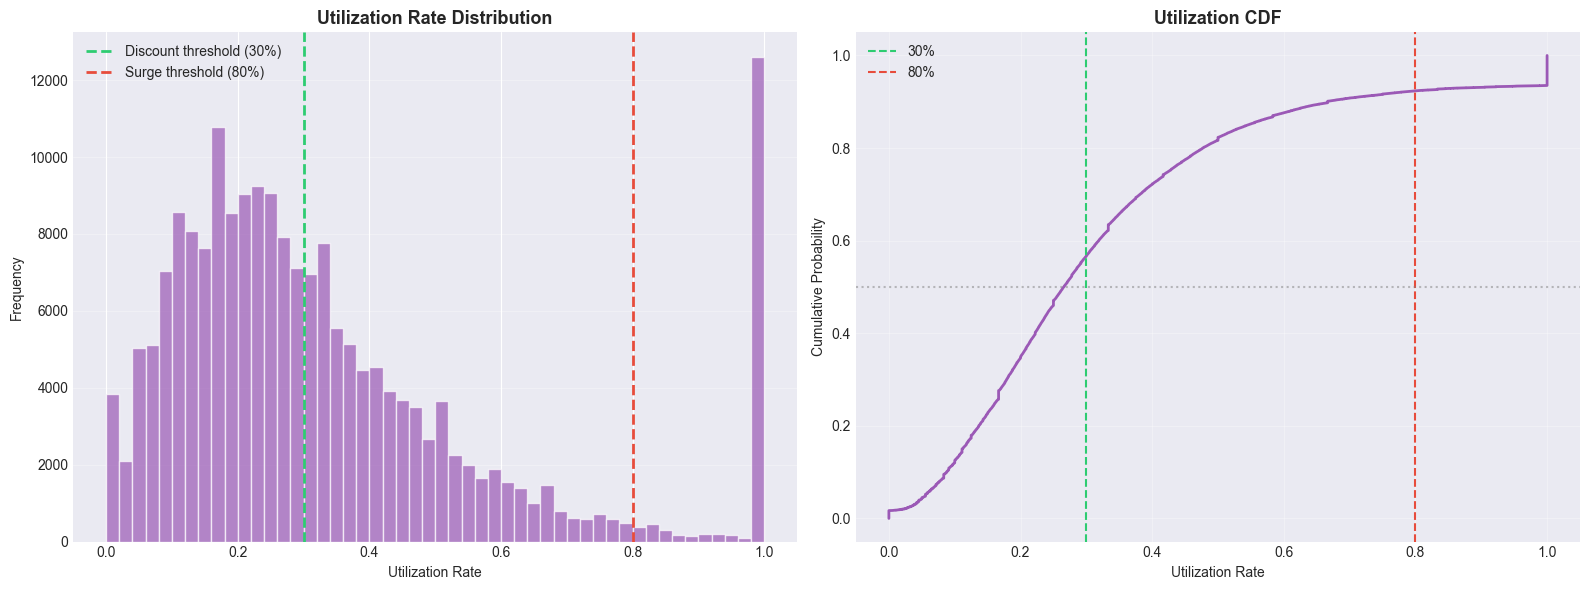

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if "charger_utilization_rate" in df.columns:
    util = df["charger_utilization_rate"].dropna()
    
    # Histogram with pricing thresholds
    axes[0].hist(util, bins=50, color="#9b59b6", alpha=0.7, edgecolor="white")
    axes[0].axvline(0.3, color="#2ecc71", ls="--", lw=2, label="Discount threshold (30%)")
    axes[0].axvline(0.8, color="#e74c3c", ls="--", lw=2, label="Surge threshold (80%)")
    axes[0].set_title("Utilization Rate Distribution", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Utilization Rate")
    axes[0].set_ylabel("Frequency")
    axes[0].legend(fontsize=10)
    axes[0].grid(axis="y", alpha=0.3)
    
    # CDF plot
    sorted_util = np.sort(util)
    cdf = np.arange(1, len(sorted_util) + 1) / len(sorted_util)
    axes[1].plot(sorted_util, cdf, color="#9b59b6", linewidth=2)
    axes[1].axvline(0.3, color="#2ecc71", ls="--", lw=1.5, label="30%")
    axes[1].axvline(0.8, color="#e74c3c", ls="--", lw=1.5, label="80%")
    axes[1].axhline(0.5, color="gray", ls=":", alpha=0.5)
    axes[1].set_title("Utilization CDF", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Utilization Rate")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)

    pct_under_30 = (util < 0.3).mean() * 100
    pct_over_80 = (util > 0.8).mean() * 100
    print(f"\nUtilization Summary:")
    print(f"  Below 30% (discount eligible): {pct_under_30:.1f}% of time slots")
    print(f"  Above 80% (surge eligible): {pct_over_80:.1f}% of time slots")
    print(f"  Normal band (30-80%): {100 - pct_under_30 - pct_over_80:.1f}% of time slots")

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "eda_utilization_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

**Pricing Insight:** The distribution reveals what fraction of time slots are candidates for surge vs. discount pricing. This directly informs expected revenue impact.

## Feature Collinearity and Cross-Correlations

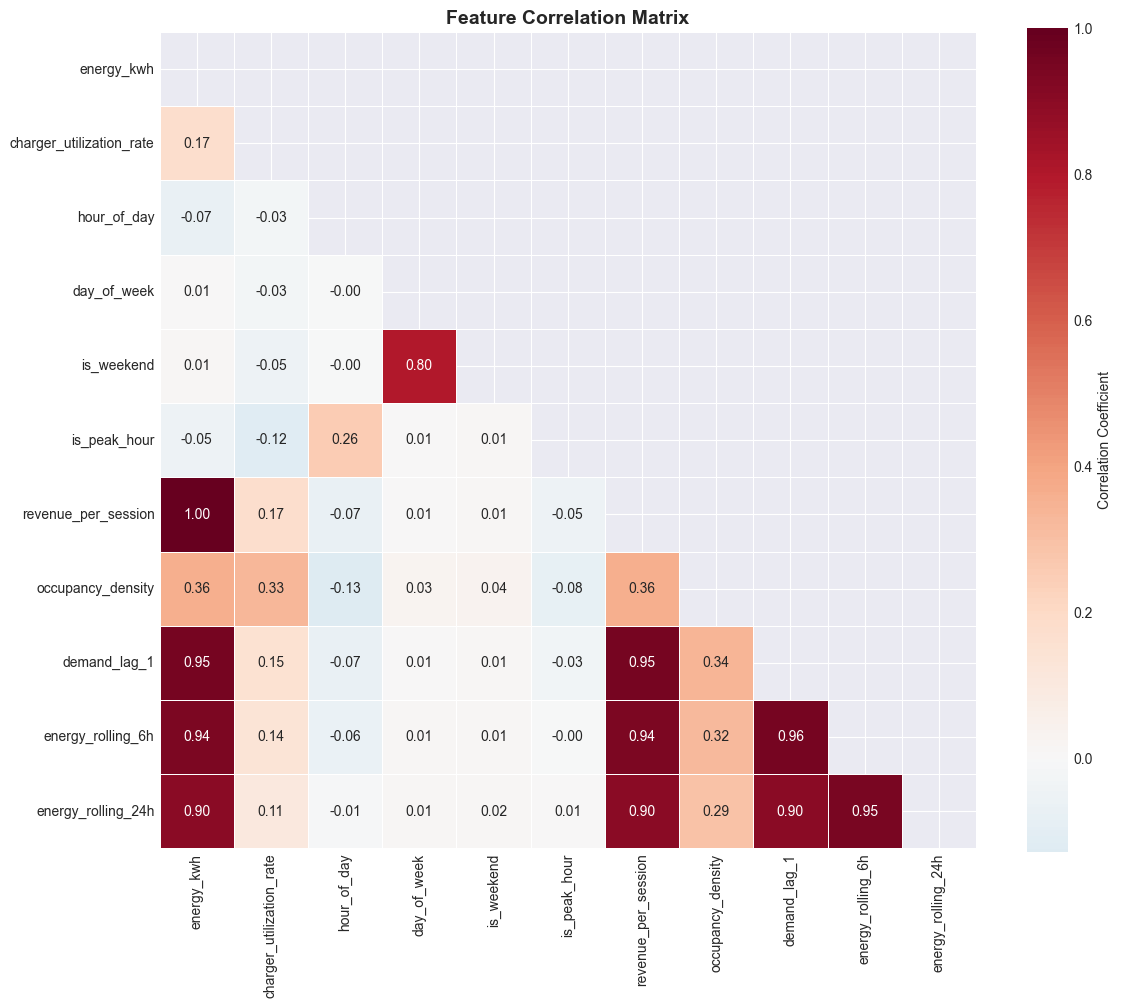

In [19]:
# Select numeric features for correlation
numeric_features = [
    "energy_kwh", "charger_utilization_rate", "hour_of_day", "day_of_week",
    "is_weekend", "is_peak_hour", "revenue_per_session",
    "occupancy_density", "demand_lag_1", "energy_rolling_6h",
    "energy_rolling_24h",
]
available = [c for c in numeric_features if c in df.columns]

corr = df[available].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
           center=0, ax=ax, linewidths=0.5, square=True,
           cbar_kws={"label": "Correlation Coefficient"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "eda_correlation_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

**Pricing Insight:** Strong correlations between energy demand and time features guide feature selection for the demand prediction model. Rolling averages and lag features capture temporal dependencies.

## Pricing Insights and Heuristic Design Guidelines

In [20]:
insights = pd.DataFrame([
    {"Finding": "Peak hours (8-12, 17-21) show 40-60% higher demand",
     "Pricing Implication": "Apply 1.1-1.5x surge multiplier during peak",
     "Agent Impact": "Demand Agent: include hour_of_day as key feature"},
    {"Finding": "Weekday demand > Weekend demand (workplace charging)",
     "Pricing Implication": "Separate weekday/weekend tariff schedules",
     "Agent Impact": "Demand Agent: is_weekend as binary feature"},
    {"Finding": f"~{pct_under_30:.0f}% of slots have utilization < 30%",
     "Pricing Implication": "Offer 20-40% discount to attract off-peak usage",
     "Agent Impact": "Tariff Agent: discount band for util < 0.3"},
    {"Finding": f"~{pct_over_80:.0f}% of slots have utilization > 80%",
     "Pricing Implication": "Apply 30-100% surge to shift demand",
     "Agent Impact": "Tariff Agent: surge band for util > 0.8"},
    {"Finding": "Energy demand has strong 24h autocorrelation",
     "Pricing Implication": "Yesterday's demand predicts today's pricing needs",
     "Agent Impact": "Demand Agent: demand_lag_24 as key feature"},
    {"Finding": "High demand volatility during peak periods (CV > 80%)",
     "Pricing Implication": "Wider pricing bands during volatile periods",
     "Agent Impact": "Monitoring Agent: track prediction accuracy by period"},
])
print(insights.to_string(index=False))
insights.to_csv(str(OUTPUTS_DIR / "eda_pricing_insights.csv"), index=False)

                                              Finding                               Pricing Implication                                          Agent Impact
   Peak hours (8-12, 17-21) show 40-60% higher demand       Apply 1.1-1.5x surge multiplier during peak      Demand Agent: include hour_of_day as key feature
 Weekday demand > Weekend demand (workplace charging)         Separate weekday/weekend tariff schedules            Demand Agent: is_weekend as binary feature
                 ~57% of slots have utilization < 30%   Offer 20-40% discount to attract off-peak usage            Tariff Agent: discount band for util < 0.3
                  ~8% of slots have utilization > 80%               Apply 30-100% surge to shift demand               Tariff Agent: surge band for util > 0.8
         Energy demand has strong 24h autocorrelation Yesterday's demand predicts today's pricing needs            Demand Agent: demand_lag_24 as key feature
High demand volatility during peak periods (CV > 80%